ΕΡΓΑΣΙΑ ΜΗΧΑΝΙΚΗΣ ΜΑΘΗΣΗΣ 2025 Α ΕΞΑΜΗΝΟ

ΔΙΔΑΣΚΩΝ: ΟΡΕΣΤΗΣ ΤΕΛΕΛΗΣ

ΦΟΙΤΗΤΗΣ: ΔΗΜΗΤΡΙΟΣ ΚΩΣΤΗΡΗΣ

ΑΜ: ΜΕ25021

ΕΡΩΤΗΜΑ Β


In [24]:
import pandas as pd

In [25]:

full_set = pd.concat(
    [
        pd.read_csv("TrainingSet.csv"),
        pd.read_csv("TestSet.csv")
    ],
    ignore_index=True
)

sold_set = pd.concat(
    [
        pd.read_csv("TrainingSubset.csv"),
        pd.read_csv("TestSubset.csv")
    ],
    ignore_index=True
)

print(full_set.shape)
print(sold_set.shape)

(296048, 28)
(89124, 33)


In [26]:
unsold = full_set[full_set["QuantitySold"] == 0]
unsold[["Price", "StartingBid"]].describe()


,Price,StartingBid
count,206894.000000,206894.000000
mean,26.601741,26.599064
std,43.460936,43.458497
min,0.010000,0.010000
25%,2.990000,2.990000
50%,9.990000,9.990000
75%,29.990000,29.990000
max,299.990000,315.000000


Ιστόγραμμα απεικόνισης πωλήσεων vs απούλητων.


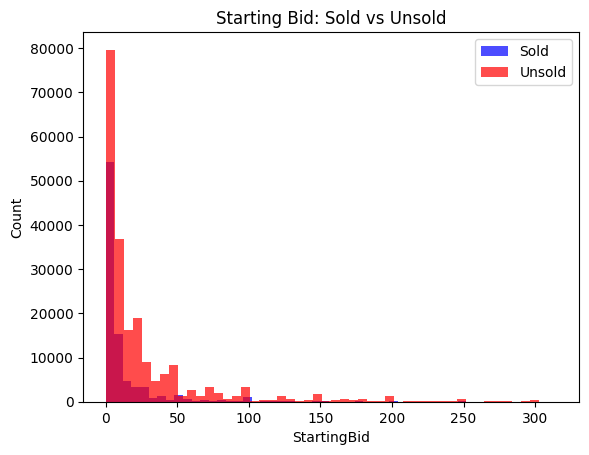

In [27]:
import matplotlib.pyplot as plt

plt.hist(sold_set["StartingBid"], bins=50, alpha=0.7, label="Sold", color = 'b')
plt.hist(unsold["StartingBid"], bins=50, alpha=0.7, label="Unsold", color = 'r')
plt.legend()
plt.xlabel("StartingBid")
plt.ylabel("Count")
plt.title("Starting Bid: Sold vs Unsold")
plt.show()


In [28]:
display(unsold)

,EbayID,QuantitySold,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,...,AuctionHitCountAvgRatio,BestOffer,ReturnsAccepted,IsHOF,ItemListedCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,AuctionMedianPrice
3,271162670857,0,10.00,0.5426,0.5426,winemeyer45,0.245098,73396,9174,10.00,...,26,0.270270,0,0,1,583,291,102,25,12.260
4,310611578768,0,9.99,1.9159,1.9159,chucksmemorabilia,0.295359,73396,17956,9.99,...,53,0.200000,0,1,0,137,44,237,70,3.020
6,261177679400,0,49.99,2.7128,2.7128,sure2mksale,0.044444,73396,9174,49.99,...,30,0.216216,0,1,1,583,291,90,4,12.260
7,300872290425,0,1.99,0.8644,0.8644,wabtrading,0.267606,73406,30356,1.99,...,9,0.133333,0,0,0,61,13,71,19,2.250
8,130862961578,0,9.99,1.9980,1.9980,ledgauges,0.038315,27278,31149,9.99,...,11,0.266667,0,1,0,13,1,7099,272,5.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296037,140966711555,0,69.95,0.8717,0.8717,kansascitycollectibles2012,0.130841,27260,19817,69.95,...,101,0.154762,0,0,0,697,280,107,14,64.995
296038,261209084199,0,79.95,0.9963,0.9963,kansascitycollectibles2012,0.130841,27260,19817,79.95,...,101,0.059524,0,0,0,697,280,107,14,64.995
296042,161016656917,0,184.99,2.3053,1.9938,anthonystephanie1,0.269953,27260,19817,159.99,...,25,0.154762,0,1,0,697,280,426,115,64.995
296044,321115331997,0,99.99,1.2460,1.2460,batboy21631,0.307692,27260,19817,99.99,...,46,0.178571,0,1,0,697,280,104,32,64.995


Ορσιμός features targets και training μοντελου.

In [29]:
from sklearn.model_selection import train_test_split

y = full_set["QuantitySold"]
X = full_set.drop(columns = ["QuantitySold", "EbayID", "Price", "PricePercent", "SellerName", "PersonID"])

#train - test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42, stratify= y)

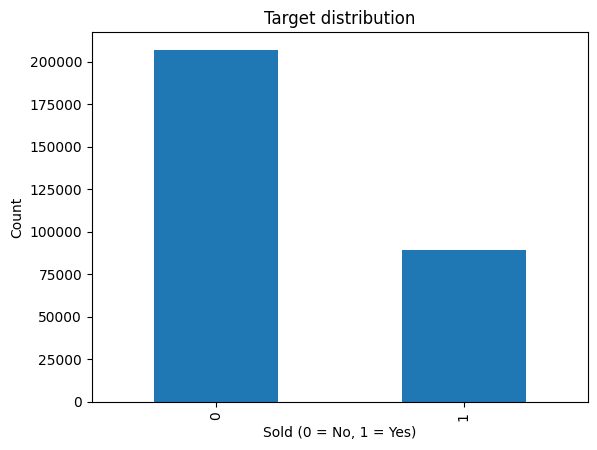

In [30]:
y.value_counts().plot(kind="bar")
plt.xlabel("Sold (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Target distribution")
plt.show()


In [31]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


QuantitySold
0    0.698851
1    0.301149
Name: proportion, dtype: float64
QuantitySold
0    0.698857
1    0.301143
Name: proportion, dtype: float64


In [32]:
#διαχωρισμός numeric με categorical τιμές

# Numeric features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

# Categorical features
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 21
Categorical features: 1


In [33]:
print(X_train.shape, X_test.shape)


(207233, 22) (88815, 22)


Προεπεξεργασία δεδομένων.

In [34]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown= "ignore"), categorical_features)

    ]
)

Αλγόριθμος 1: Logistic Regression

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_LR = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]
)


In [36]:
model_LR.fit(X_train, y_train)


/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ gr

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['StartingBidPercent', 'SellerClosePercent', 'Category', 'StartingBid',
       'AvgPrice', 'HitCount', 'AuctionAvgHitCount', 'ItemAuctionSellPercent',
       'SellerSaleAvgPriceRatio', 'SellerAvg', 'SellerItemAvg',
       'AuctionHitCountAvgRatio', 'BestOffer', 'ReturnsAccepted', 'IsHOF',
       'ItemListedCount', 'AuctionCount', 'AuctionSaleCount',
       'SellerAuctionCount', 'SellerAuctionSaleCount', 'AuctionMedianPrice'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['EndDay'], dtype='object'))])),
                ('model', LogisticRegression(max_iter=2000))])

LR Metrics

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

y_predLR = model_LR.predict(X_test)

/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [38]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_predLR))

Confusion matrix:
 [[59327  2742]
 [ 7182 19564]]


Αλγόριθμος 2: linear SVM

In [39]:
from sklearn.svm import LinearSVC


In [40]:
model_SVM = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LinearSVC(
            C= 1.0,
            max_iter= 5000))
    ]
)

In [41]:
model_SVM.fit(X_train, y_train)
y_pred_svm = model_SVM.predict(X_test)

/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [42]:
print("Classification report LR:\n\n",classification_report(y_test, y_predLR, digits=4))
print("\nConfusion matrix (Logisitic regression):\n\n", confusion_matrix(y_test, y_predLR))


Classification report LR:

               precision    recall  f1-score   support

           0     0.8920    0.9558    0.9228     62069
           1     0.8771    0.7315    0.7977     26746

    accuracy                         0.8883     88815
   macro avg     0.8845    0.8436    0.8603     88815
weighted avg     0.8875    0.8883    0.8851     88815


Confusion matrix (Logisitic regression):

 [[59327  2742]
 [ 7182 19564]]


In [43]:
print("\nClassification report SVM\n\n",classification_report(y_test, y_pred_svm, digits = 4))
print("\nConfusion matrix (SVM):\n\n", confusion_matrix(y_test, y_pred_svm))


Classification report SVM

               precision    recall  f1-score   support

           0     0.8852    0.9608    0.9215     62069
           1     0.8866    0.7109    0.7891     26746

    accuracy                         0.8856     88815
   macro avg     0.8859    0.8359    0.8553     88815
weighted avg     0.8856    0.8856    0.8816     88815


Confusion matrix (SVM):

 [[59636  2433]
 [ 7731 19015]]


In [44]:
test_accLR = model_LR.score(X_test, y_test)
train_accLR = model_LR.score(X_train, y_train)

test_accSVM = model_SVM.score(X_test, y_test)
train_accSVM = model_SVM.score(X_train, y_train)

print("\nTrain accuracy LR:", train_accLR)
print("\nTest accuracy LR:", test_accLR)

print("\n\n\nTrain accuracy SVM:", train_accSVM)
print("\nTest accuracy SVM:", test_accSVM,"\n\n")


Train accuracy LR: 0.887865349630609

Test accuracy LR: 0.8882621178854924



Train accuracy SVM: 0.8851679027954042

Test accuracy SVM: 0.8855598716433035 




/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: Runt

In [45]:
from sklearn.metrics import roc_auc_score

y_probaLR = model_LR.predict_proba(X_test)[:, 1]
aucLR = roc_auc_score(y_test, y_probaLR)


print("ROC-AUC LR:", aucLR,"\n")


ROC-AUC LR: 0.938328968567541 



/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
